# Specific Stocks Simulation

Run the prediction pipeline for a custom ticker list, review the summaries, and plot a manual buy point against the stock price history.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd

import analysis_blocks


## Block 1: Parameters


In [2]:
tickers = [
    "FWRG",
]
initial_funds = 1000
include_fundamentals = True
include_sentiment = False  # True requires API keys and adds latency

manual_positions = {
    "FWRG": {
        "buy_date": "2025-01-15",
        "buy_price": 18.25,
        "units": 25,
    },
}

chart_ticker = "FWRG"
chart_days_before_buy = 30


## Block 2: Run Workflow


In [3]:
result = analysis_blocks.run_specific_stock_simulation_workflow(
    tickers=tickers,
    initial_funds=initial_funds,
    include_sentiment=include_sentiment,
    include_fundamentals=include_fundamentals,
)


## Block 3: Workflow Summaries


In [4]:
result["prediction_summary"]


,current_date,TICKER,Signal,Signal_Text,cumulative_return,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio
0,20260314,FWRG,0,HOLD,Negative: Poor,Negative: Poor,Negative: Unacceptable,Positive: Good,Negative: Poor


In [5]:
result["exploratory_simulation_summary"]


,current_date,TICKER,closing_stock_price,final_cash_balance,unrealized_gains_losses,unrealized_gain_loss_%,units_held,average_price_per_unit,signal_text,signal_number
0,20260314,FWRG,11.7,1000,0.0,0,0,0,HOLD,0


## Block 4: Manual Buy Position Summary


In [6]:
manual_position_views = {}
for ticker, position in manual_positions.items():
    if ticker not in result["analyses"]:
        raise KeyError(f"{ticker} is not in result['analyses']. Check tickers and manual_positions.")

    manual_position_views[ticker] = analysis_blocks.build_manual_position_analysis(
        result["analyses"][ticker]["df_pred"],
        buy_date=position["buy_date"],
        buy_price=position["buy_price"],
        units=position.get("units", 1),
    )

manual_position_summary = (
    pd.concat(
        [
            view["summary"].assign(TICKER=ticker)[
                [
                    "TICKER",
                    "requested_buy_date",
                    "resolved_buy_date",
                    "buy_date_resolution",
                    "buy_price",
                    "reference_close_on_resolved_date",
                    "units",
                    "latest_date",
                    "latest_close",
                    "cost_basis",
                    "market_value",
                    "pnl",
                    "pnl_pct",
                ]
            ]
            for ticker, view in manual_position_views.items()
        ],
        ignore_index=True,
    )
    if manual_position_views
    else pd.DataFrame()
)

manual_position_summary


,TICKER,requested_buy_date,resolved_buy_date,buy_date_resolution,buy_price,reference_close_on_resolved_date,units,latest_date,latest_close,cost_basis,market_value,pnl,pnl_pct
0,FWRG,2025-01-15,2025-01-15,exact,18.25,18.57,25.0,2026-03-13,11.53,456.25,288.249993,-168.000007,-36.821919


## Block 5: Price Chart With Buy Marker


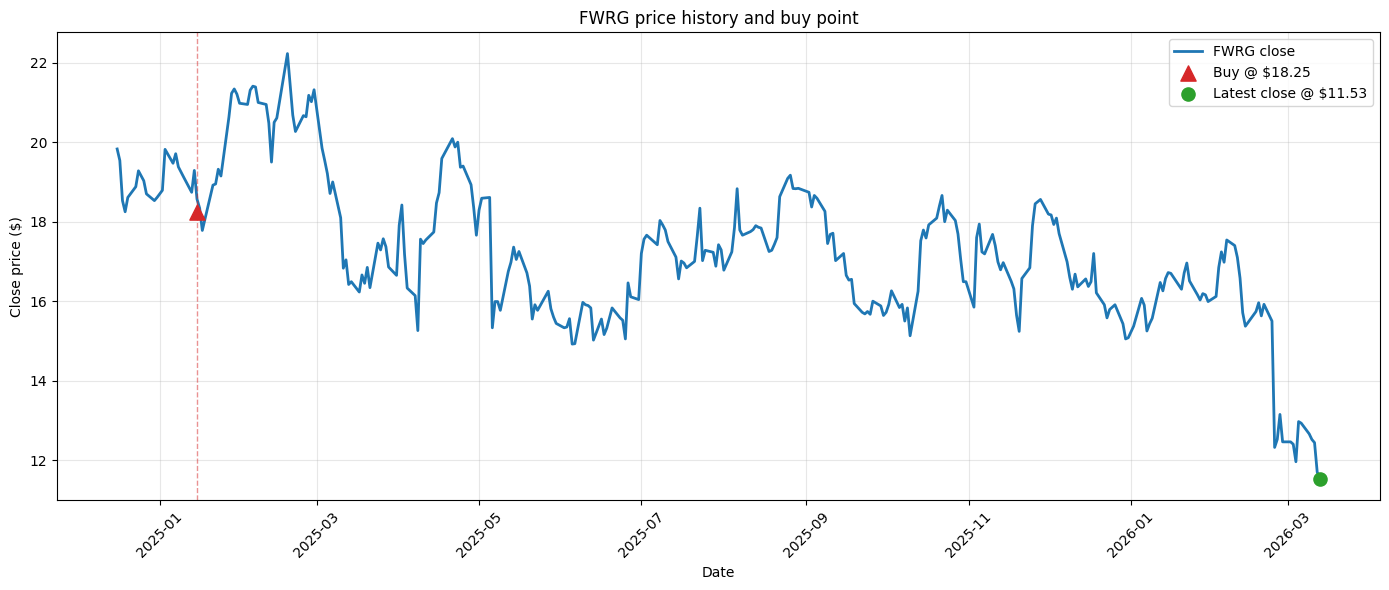

In [7]:
if chart_ticker not in manual_position_views:
    raise KeyError(f"Add {chart_ticker} to manual_positions before rendering the chart.")

position_view = manual_position_views[chart_ticker]
price_history = position_view["price_history"].copy()
buy_marker = position_view["buy_marker"].iloc[0]
window_start = buy_marker["Date"] - pd.Timedelta(days=chart_days_before_buy)
price_window = price_history[price_history["Date"] >= window_start].copy()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(price_window["Date"], price_window["Close"], color="#1f77b4", linewidth=2, label=f"{chart_ticker} close")
ax.scatter(
    buy_marker["Date"],
    buy_marker["Close"],
    color="#d62728",
    s=120,
    marker="^",
    label=f"Buy @ ${buy_marker['Close']:.2f}",
    zorder=5,
)
ax.axvline(buy_marker["Date"], color="#d62728", linestyle="--", linewidth=1, alpha=0.5)

latest_point = price_window.iloc[-1]
ax.scatter(
    latest_point["Date"],
    latest_point["Close"],
    color="#2ca02c",
    s=90,
    label=f"Latest close @ ${latest_point['Close']:.2f}",
    zorder=5,
)

resolution_note = ""
if buy_marker["buy_date_resolution"] != "exact":
    resolution_note = (
        f" (requested {buy_marker['requested_buy_date'].date()}, used {buy_marker['Date'].date()})"
    )

ax.set_title(f"{chart_ticker} price history and buy point{resolution_note}")
ax.set_xlabel("Date")
ax.set_ylabel("Close price ($)")
ax.grid(alpha=0.3)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
